In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import os, glob
import h5py

import sys
sys.path.append('../../')
import analysis_utils as utils
utils.load_plotting_setting()

import calc_gas_collision_spectrum as calc_gas

In [2]:
import importlib
importlib.reload(utils)
importlib.reload(calc_gas)

<module 'calc_gas_collision_spectrum' from '/Users/yuhan/work/nanospheres/gas_collisiions/analysis_notebooks/sphere_20260215/../../calc_gas_collision_spectrum.py'>

In [19]:
sphere = 'sphere_20260215'
amp2kev = 8363.560351624732

def read_recon(file):
    f = h5py.File(file, 'r')
    try:
        pressure = f['data_processed'].attrs['pressure_mbar']

        amps = f['data_processed']['amplitude'][:]
        good_detection = f['data_processed']['good_detection'][:]
        noise_level_amp = f['data_processed']['noise_level_amp'][:]
        chi2 = f['data_processed']['chisquare'][:]
        f_res = f['data_processed']['f_res'][:]
        driven_power = f['data_processed']['driven_power'][:]

        f.close()

        return amps, good_detection, noise_level_amp, chi2, f_res, driven_power, pressure
    except:
        f.close()

def read_recon_all(dataset, type, file_prefix, nfiles):
    amps_all, good_detection_all, noise_level_all, chi2_all, driven_power_all, f_res_all, pressure_all = [], [], [], [], [], [], []
    for i in range(nfiles):
        file = rf'/Users/yuhan/work/nanospheres/data/gas_data_processed/{sphere}/{type}/{dataset}/{file_prefix}{i}_processed.hdf5'
        amps, good_detection, noise_level_amp, chi2, f_res, driven_power, pressure = read_recon(file)

        amps_all.append(amps)
        good_detection_all.append(good_detection)
        noise_level_all.append(noise_level_amp)
        chi2_all.append(chi2)
        driven_power_all.append(driven_power)
        f_res_all.append(f_res)
        pressure_all.append(pressure)

    return [amps_all, good_detection_all, noise_level_all, chi2_all, driven_power_all, f_res_all, pressure_all]

def get_summed_histogram(recon_output, amp2kev, noise_threshold_kev=70, chi2_threshold=700, normalized_drive_power_threshold=1.75e-8):
    amps, good_detection, noise_level_amp, chi2, driven_power, f_res = [recon_output[i] for i in range(6)]

    drive_freq = 137000
    ref_freq = 48500

    bins = np.arange(0, 2000, 25)  # keV
    bc = 0.5 * (bins[:-1] + bins[1:])
    hh_all = np.zeros_like(bc, dtype=np.int64)

    for i in range(len(good_detection)):
        _good_window = np.logical_and(good_detection[i], noise_level_amp[i]*amp2kev < noise_threshold_kev)
    
        normalized_drive_power = driven_power[i] * (f_res[i]**2 - drive_freq**2)**2 / ((ref_freq**2 - drive_freq**2)**2)
        good_window = np.logical_and(_good_window, normalized_drive_power > normalized_drive_power_threshold)

        _good_amps = amps[i][good_window]
        _good_amps_chi2 = chi2[i][good_window]

        good_amps = _good_amps[_good_amps_chi2 < chi2_threshold]
        _hh, _ = np.histogram(np.abs(good_amps) * amp2kev, bins)

        hh_all += _hh

    return bc, hh_all

In [30]:
datasets_bg = ['20260219_p6e_4e-8mbar', '20260219_p6e_3e-8mbar_xevalveclosed', '20260219_p6e_3e-8mbar_krvalveclosed', '20260219_p6e_3e-8mbar_sf6valveclosed']

recon_bg_0 = read_recon_all(datasets_bg[0], 'background_data', '20260219_dfg_', 25)
recon_bg_1 = read_recon_all(datasets_bg[1], 'background_data', '20260219_dfg_', 25)
recon_bg_2 = read_recon_all(datasets_bg[2], 'background_data', '20260219_dfg_', 25)
recon_bg_3 = read_recon_all(datasets_bg[3], 'background_data', '20260219_dfg_', 25)

recon_bg_all = [recon_bg_0, recon_bg_1, recon_bg_2, recon_bg_3]


In [8]:
datasets_xe = ['20260219_p6e_1e-6mbar', '20260219_p6e_8e-7mbar', '20260219_p6e_4e-7mbar_1', '20260219_p6e_2e-7mbar', '20260219_p6e_1e-7mbar_1', '20260219_p6e_7e-8mbar', '20260219_p6e_5e-8mbar']

recon_xe_0 = read_recon_all(datasets_xe[0], 'xenon_data', '20260219_dfg_', 25)
recon_xe_1 = read_recon_all(datasets_xe[1], 'xenon_data', '20260219_dfg_', 25)
recon_xe_2 = read_recon_all(datasets_xe[2], 'xenon_data', '20260219_dfg_', 25)
recon_xe_3 = read_recon_all(datasets_xe[3], 'xenon_data', '20260219_dfg_', 25)
recon_xe_4 = read_recon_all(datasets_xe[4], 'xenon_data', '20260219_dfg_', 25)
recon_xe_5 = read_recon_all(datasets_xe[5], 'xenon_data', '20260219_dfg_', 25)
recon_xe_6 = read_recon_all(datasets_xe[6], 'xenon_data', '20260219_dfg_', 25)

recon_xe_all = [recon_xe_0, recon_xe_1, recon_xe_2, recon_xe_3, recon_xe_4, recon_xe_5, recon_xe_6]


In [38]:
datasets_kr = ['20260219_p6e_1e-6mbar', '20260219_p6e_7e-7mbar', '20260219_p6e_5e-7mbar', '20260219_p6e_2e-7mbar', '20260219_p6e_1e-7mbar', '20260219_p6e_7e-8mbar', '20260219_p6e_5e-8mbar']

recon_kr_0 = read_recon_all(datasets_kr[0], 'krypton_data', '20260219_dfg_', 25)
recon_kr_1 = read_recon_all(datasets_kr[1], 'krypton_data', '20260219_dfg_', 25)
recon_kr_2 = read_recon_all(datasets_kr[2], 'krypton_data', '20260219_dfg_', 25)
recon_kr_3 = read_recon_all(datasets_kr[3], 'krypton_data', '20260219_dfg_', 25)
recon_kr_4 = read_recon_all(datasets_kr[4], 'krypton_data', '20260219_dfg_', 25)
recon_kr_5 = read_recon_all(datasets_kr[5], 'krypton_data', '20260219_dfg_', 25)
recon_kr_6 = read_recon_all(datasets_kr[6], 'krypton_data', '20260219_dfg_', 25)

recon_kr_all = [recon_kr_0, recon_kr_1, recon_kr_2, recon_kr_3, recon_kr_4, recon_kr_5, recon_kr_6]


In [47]:
datasets_sf6 = ['20260219_p6e_1e-6mbar', '20260219_p6e_7e-7mbar', '20260219_p6e_5e-7mbar', '20260219_p6e_3e-7mbar_1', '20260219_p6e_1e-7mbar', '20260219_p6e_7e-8mbar', '20260219_p6e_5e-8mbar']

recon_sf6_0 = read_recon_all(datasets_sf6[0], 'sf6_data', '20260219_dfg_', 25)
recon_sf6_1 = read_recon_all(datasets_sf6[1], 'sf6_data', '20260219_dfg_', 25)
recon_sf6_2 = read_recon_all(datasets_sf6[2], 'sf6_data', '20260219_dfg_', 25)
recon_sf6_3 = read_recon_all(datasets_sf6[3], 'sf6_data', '20260219_dfg_', 25)
recon_sf6_4 = read_recon_all(datasets_sf6[4], 'sf6_data', '20260219_dfg_', 25)
recon_sf6_5 = read_recon_all(datasets_sf6[5], 'sf6_data', '20260219_dfg_', 25)
recon_sf6_6 = read_recon_all(datasets_sf6[6], 'sf6_data', '20260219_dfg_', 25)

recon_sf6_all = [recon_sf6_0, recon_sf6_1, recon_sf6_2, recon_sf6_3, recon_sf6_4, recon_sf6_5, recon_sf6_6]

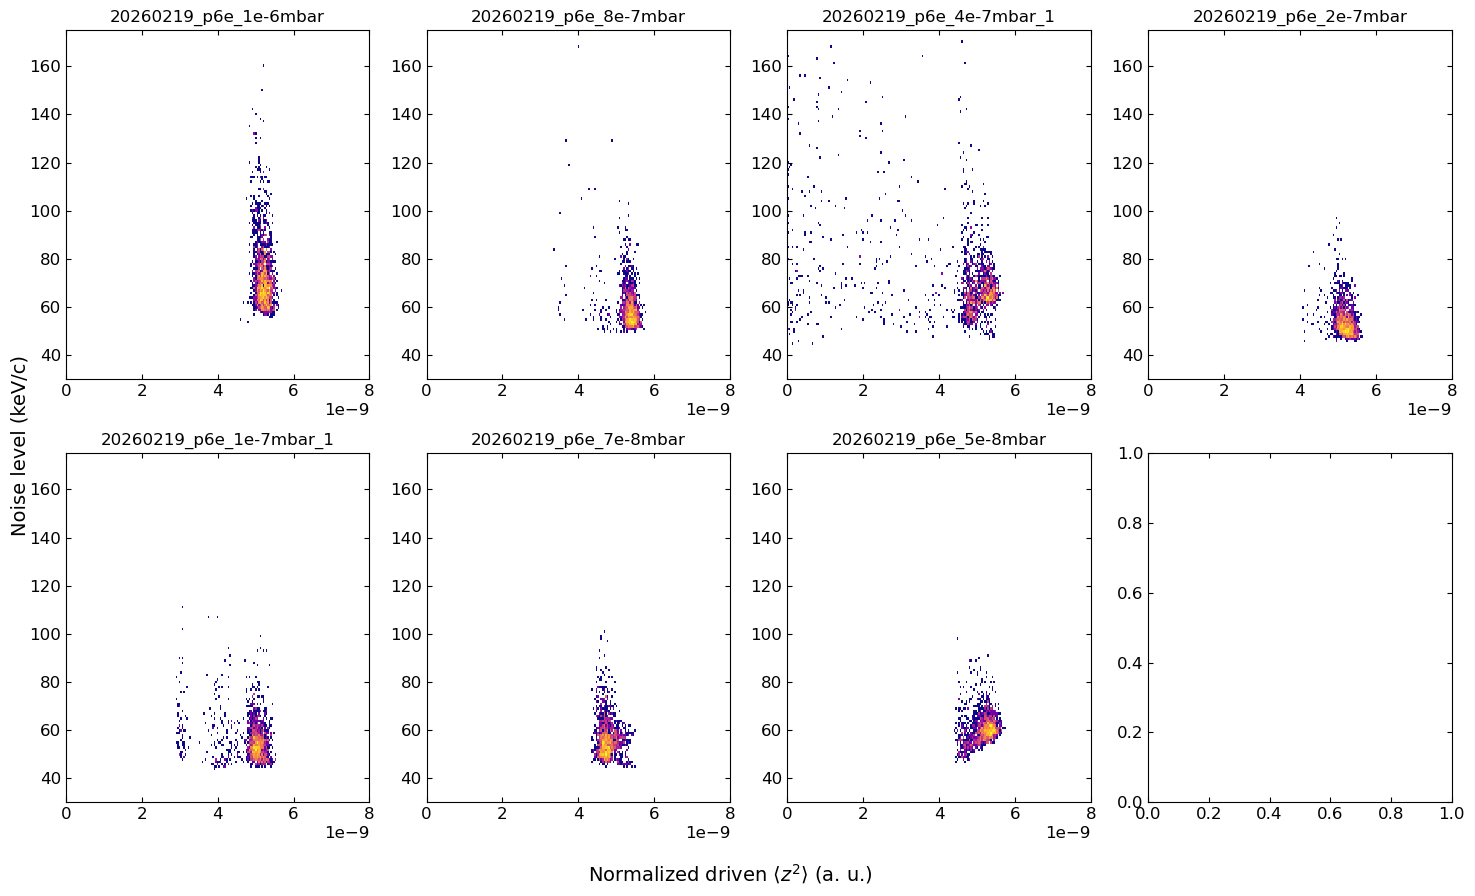

In [12]:
xbins = np.linspace(0, 8e-9, 200)
ybins = np.linspace(0, 200, 200)

fig, axes = plt.subplots(2, 4, figsize=(15, 9))
for i in range(len(datasets_xe)):
    ax = axes.flatten()[i]

    _drive = np.concatenate(recon_xe_all[i][4])
    _freq  = np.concatenate(recon_xe_all[i][5])
    drive_freq = 137000
    ref_freq = 48500
    normalized_drive_power = _drive * (_freq**2 - drive_freq**2)**2 / ((ref_freq**2 - drive_freq**2)**2)

    hh, _, _ = np.histogram2d(x=normalized_drive_power, y=np.concatenate(recon_xe_all[i][2])*amp2kev, bins=(xbins, ybins))
    pc = ax.pcolormesh(xbins, ybins, hh.T, norm=mcolors.LogNorm(), cmap='plasma')

    ax.set_xlim(0, 8e-9)
    ax.set_ylim(30, 175)
    ax.set_title(datasets_xe[i], fontsize=12)

fig.supxlabel(r'Normalized driven $\langle z^2 \rangle$ (a. u.)', fontsize=14)
fig.supylabel(r'Noise level (keV/c)', fontsize=14)
fig.tight_layout()


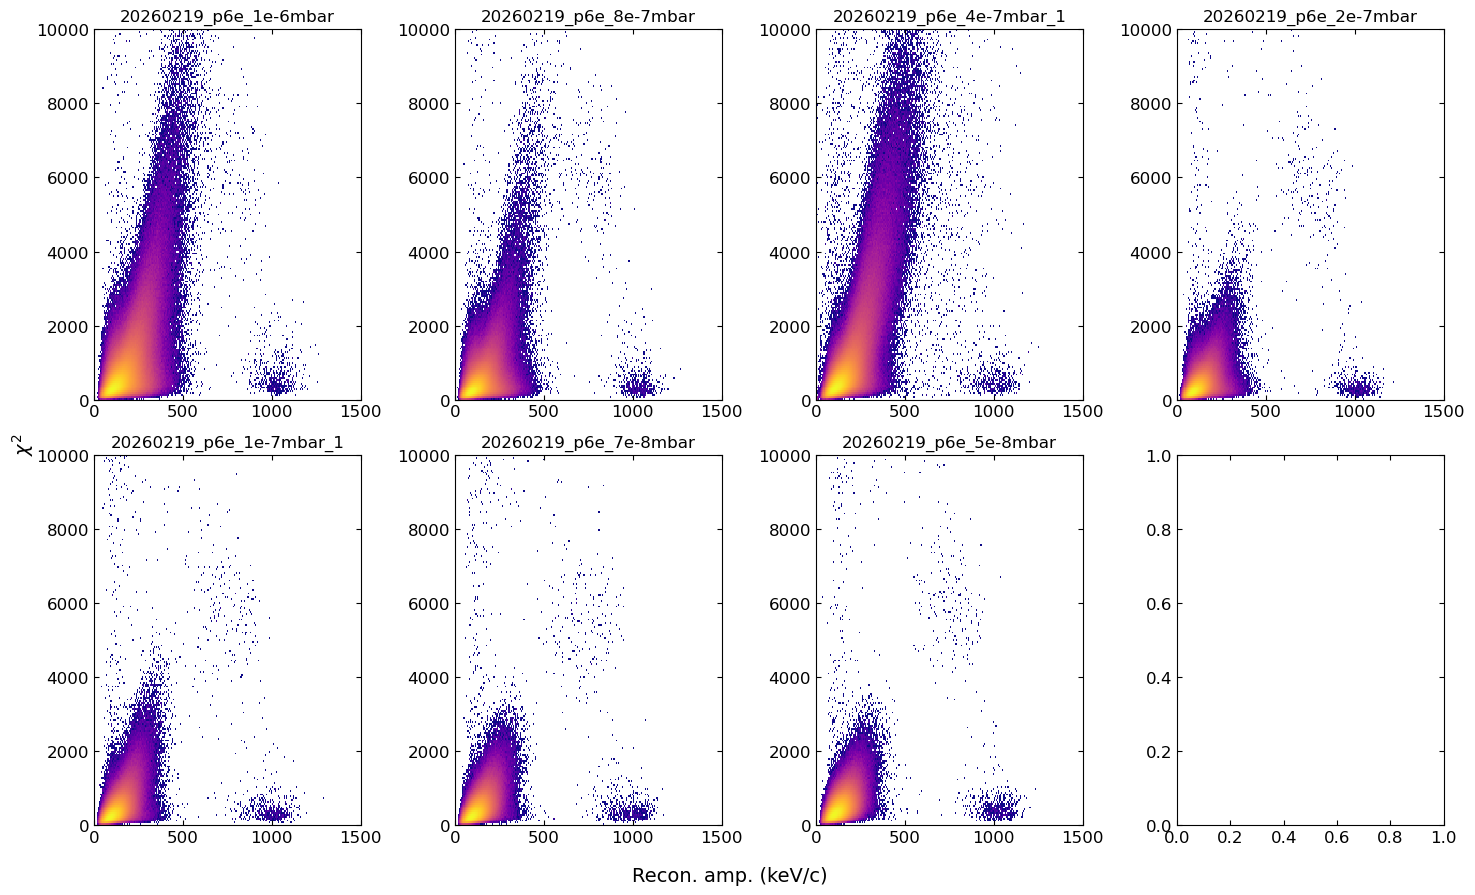

In [14]:
xbins = np.linspace(0, 1500, 250)
ybins = np.linspace(0, 10000, 200)

fig, axes = plt.subplots(2, 4, figsize=(15, 9))
for i in range(len(datasets_xe)):
    ax = axes.flatten()[i]

    hh, _, _ = np.histogram2d(x=np.concatenate(np.abs(recon_xe_all[i][0])).flatten()*amp2kev, y=np.concatenate(recon_xe_all[i][3]).flatten(), bins=(xbins, ybins))
    pc = ax.pcolormesh(xbins, ybins, hh.T, norm=mcolors.LogNorm(), cmap='plasma')

    ax.set_title(datasets_xe[i], fontsize=12)

fig.supxlabel(r'Recon. amp. (keV/c)', fontsize=14)
fig.supylabel(r'$\chi^2$', fontsize=14)
fig.tight_layout()


In [ ]:
bc, hh_all_bg_1 = get_summed_histogram(recon_bg_1, amp2kev, noise_threshold_kev=70, chi2_threshold=700, normalized_drive_power_threshold=4.5e-9)
bc, hh_all_bg_2 = get_summed_histogram(recon_bg_2, amp2kev, noise_threshold_kev=70, chi2_threshold=700, normalized_drive_power_threshold=4.5e-9)
bc, hh_all_bg_3 = get_summed_histogram(recon_bg_3, amp2kev, noise_threshold_kev=70, chi2_threshold=700, normalized_drive_power_threshold=4.5e-9)

In [28]:
bc, hh_all_xe_0 = get_summed_histogram(recon_xe_0, amp2kev, noise_threshold_kev=70, chi2_threshold=700, normalized_drive_power_threshold=4.5e-9)
bc, hh_all_xe_1 = get_summed_histogram(recon_xe_1, amp2kev, noise_threshold_kev=70, chi2_threshold=700, normalized_drive_power_threshold=4.5e-9)
bc, hh_all_xe_2 = get_summed_histogram(recon_xe_2, amp2kev, noise_threshold_kev=70, chi2_threshold=700, normalized_drive_power_threshold=4.5e-9)
bc, hh_all_xe_3 = get_summed_histogram(recon_xe_3, amp2kev, noise_threshold_kev=70, chi2_threshold=700, normalized_drive_power_threshold=4.5e-9)
bc, hh_all_xe_4 = get_summed_histogram(recon_xe_4, amp2kev, noise_threshold_kev=70, chi2_threshold=700, normalized_drive_power_threshold=4.5e-9)
bc, hh_all_xe_5 = get_summed_histogram(recon_xe_5, amp2kev, noise_threshold_kev=70, chi2_threshold=700, normalized_drive_power_threshold=4.5e-9)
bc, hh_all_xe_6 = get_summed_histogram(recon_xe_6, amp2kev, noise_threshold_kev=70, chi2_threshold=700, normalized_drive_power_threshold=4.5e-9)

In [40]:
bc, hh_all_kr_0 = get_summed_histogram(recon_kr_0, amp2kev, noise_threshold_kev=70, chi2_threshold=700, normalized_drive_power_threshold=4.5e-9)
bc, hh_all_kr_1 = get_summed_histogram(recon_kr_1, amp2kev, noise_threshold_kev=70, chi2_threshold=700, normalized_drive_power_threshold=4.5e-9)
bc, hh_all_kr_2 = get_summed_histogram(recon_kr_2, amp2kev, noise_threshold_kev=70, chi2_threshold=700, normalized_drive_power_threshold=4.5e-9)
bc, hh_all_kr_3 = get_summed_histogram(recon_kr_3, amp2kev, noise_threshold_kev=70, chi2_threshold=700, normalized_drive_power_threshold=4.5e-9)
bc, hh_all_kr_4 = get_summed_histogram(recon_kr_4, amp2kev, noise_threshold_kev=70, chi2_threshold=700, normalized_drive_power_threshold=4.5e-9)
bc, hh_all_kr_5 = get_summed_histogram(recon_kr_5, amp2kev, noise_threshold_kev=70, chi2_threshold=700, normalized_drive_power_threshold=4.5e-9)
bc, hh_all_kr_6 = get_summed_histogram(recon_kr_6, amp2kev, noise_threshold_kev=70, chi2_threshold=700, normalized_drive_power_threshold=4.5e-9)

In [48]:
bc, hh_all_sf6_0 = get_summed_histogram(recon_sf6_0, amp2kev, noise_threshold_kev=70, chi2_threshold=700, normalized_drive_power_threshold=4.5e-9)
bc, hh_all_sf6_1 = get_summed_histogram(recon_sf6_1, amp2kev, noise_threshold_kev=70, chi2_threshold=700, normalized_drive_power_threshold=4.5e-9)
bc, hh_all_sf6_2 = get_summed_histogram(recon_sf6_2, amp2kev, noise_threshold_kev=70, chi2_threshold=700, normalized_drive_power_threshold=4.5e-9)
bc, hh_all_sf6_3 = get_summed_histogram(recon_sf6_3, amp2kev, noise_threshold_kev=70, chi2_threshold=700, normalized_drive_power_threshold=4.5e-9)
bc, hh_all_sf6_4 = get_summed_histogram(recon_sf6_4, amp2kev, noise_threshold_kev=70, chi2_threshold=700, normalized_drive_power_threshold=4.5e-9)
bc, hh_all_sf6_5 = get_summed_histogram(recon_sf6_5, amp2kev, noise_threshold_kev=70, chi2_threshold=700, normalized_drive_power_threshold=4.5e-9)
bc, hh_all_sf6_6 = get_summed_histogram(recon_sf6_6, amp2kev, noise_threshold_kev=70, chi2_threshold=700, normalized_drive_power_threshold=4.5e-9)

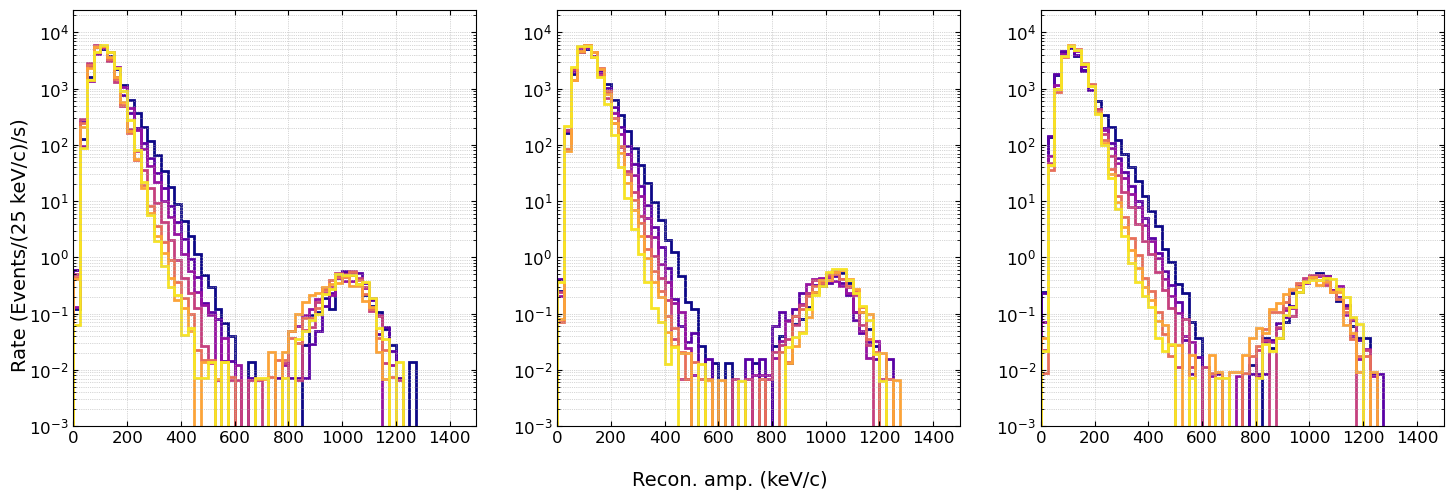

In [53]:
hhs_all_bg = [hh_all_bg_0, hh_all_bg_1, hh_all_bg_2, hh_all_bg_3]
hhs_all_xe = [hh_all_xe_0, hh_all_xe_1, hh_all_xe_2, hh_all_xe_3, hh_all_xe_4, hh_all_xe_5, hh_all_xe_6]
hhs_all_kr = [hh_all_kr_0, hh_all_kr_1, hh_all_kr_2, hh_all_kr_3, hh_all_kr_4, hh_all_kr_5, hh_all_kr_6]
hhs_all_sf6 = [hh_all_sf6_0, hh_all_sf6_1, hh_all_sf6_2, hh_all_sf6_3, hh_all_sf6_4, hh_all_sf6_5, hh_all_sf6_6]


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

cmap = plt.colormaps.get_cmap('plasma')
colors = cmap(np.linspace(0, 0.95, 7))

bins = np.arange(0, 2000, 25)
for i in range(len(hhs_all_xe)):
    axes[0].stairs(hhs_all_xe[i]/(50e-6 * np.sum(hhs_all_xe[i])), edges=bins, color=colors[i], linewidth=2)
    axes[1].stairs(hhs_all_kr[i]/(50e-6 * np.sum(hhs_all_kr[i])), edges=bins, color=colors[i], linewidth=2)
    axes[2].stairs(hhs_all_sf6[i]/(50e-6 * np.sum(hhs_all_sf6[i])), edges=bins, color=colors[i], linewidth=2)

# for ax in axes:
#     for i in range(len(hhs_all_bg)):
#         ax.stairs(hhs_all_bg[i]/(50e-6 * np.sum(hhs_all_bg[i])), edges=bins, color='k', linestyle='--', linewidth=1)

for ax in axes:
    ax.set_yscale('log')
    ax.set_xlim(0, 1500)
    ax.set_ylim(1e-3, 2.5e4)

    ax.grid(which='both', ls=':', linewidth=0.5)

fig.supxlabel('Recon. amp. (keV/c)', fontsize=14)
fig.supylabel('Rate (Events/(25 keV/c)/s)', fontsize=14)
fig.tight_layout()


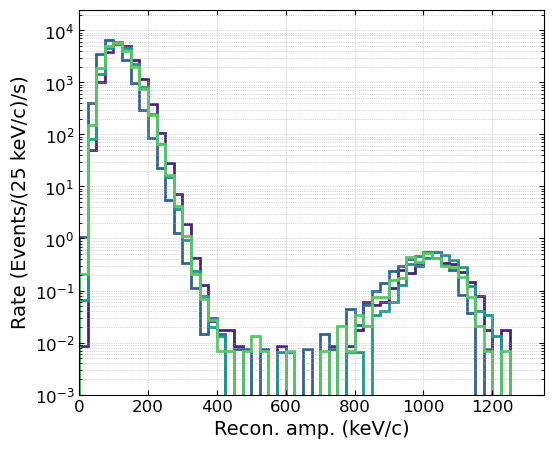

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))

bins = np.arange(0, 2000, 25)
for i in range(len(hhs_all_bg)):
    ax.stairs(hhs_all_bg[i]/(50e-6 * np.sum(hhs_all_bg[i])), edges=bins, linewidth=2)

ax.set_yscale('log')
ax.set_xlim(0, 1350)
ax.set_ylim(1e-3, 2.5e4)

ax.set_xlabel('Recon. amp. (keV/c)')
ax.set_ylabel('Rate (Events/(25 keV/c)/s)')

ax.grid(which='both', ls=':', linewidth=0.5)
